In [38]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier)
from sklearn.model_selection import train_test_split, validation_curve, RandomizedSearchCV
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve, RocCurveDisplay)
import matplotlib.pyplot as plt
import SurvivalToDischarge

In [2]:
X, y = SurvivalToDischarge.load_data(sample_size=100000, icu_vitals=True, top_n_labs=230, top_n_drugs=954, top_n_procedures=55)

Returing 100000 patient records with 660 columns. y distribution: 
hospital_expire_flag
0    0.97966
1    0.02034
Name: proportion, dtype: float64


In [3]:
import joblib
lasso_model = joblib.load('results/lasso_model.joblib')

In [25]:
coefs.head(10)

,Unnamed: 0,0
659,anchor_age,0.920819
0,drug_warfarin,-0.432824
658,drug_morphine_sulfate,0.398225
1,drug_heparin,-0.312938
657,drug_scopolamine_patch,0.285381
656,vital_mean_heart_rate,0.279714
655,admission_type_EW EMER.,0.249453
654,lab_lactate,0.241904
653,lab_anion_gap,0.241010
2,drug_docusate_sodium,-0.237507


ValueError: not enough values to unpack (expected 2, got 0)

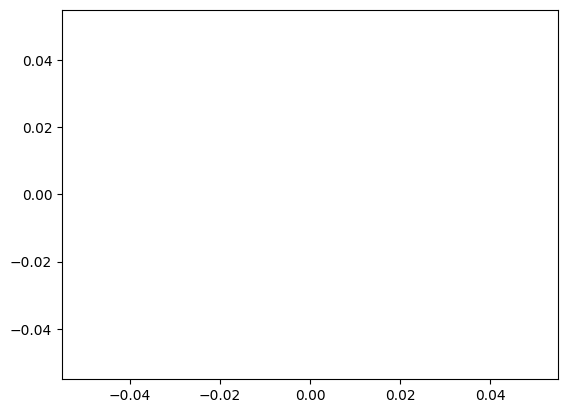

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
coefs = pd.read_csv('results/coef_series.csv')
coefs = coefs.assign(_abs=coefs['0'].abs()).sort_values('_abs', ascending=False).drop(columns='_abs')
fig, axes = plt.plot()

top_coef = coefs.head(10)
axes[0].barh(top_coef.index[::-1], top_coef['0'].values[::-1], color='tomato')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Negative Features by Coefficient')
axes[0].tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

In [13]:
# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 225), Test: (20000, 225)


In [16]:
print(X_train.shape)
X_train.head(20)

(80000, 225)


,anchor_age,vital_mean_heart_rate,vital_max_temperature_f,vital_min_heart_rate,vital_min_respiratory_rate,vital_min_spo2,vital_min_temperature_f,lab_absolute_lymphocyte_count,lab_albumin,"lab_albumin,_ascites",...,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_PACU,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,insurance_Other,race_WHITE
51787,68,83.030331,99.2,64.0,10.0,91.0,97.5,0.281667,3.20,1.1,...,0,0,0,0,0,0,0,0,0,1
13940,37,88.171429,99.1,75.0,0.0,94.0,97.5,1.300000,2.90,1.1,...,0,0,0,0,0,0,1,0,0,0
14934,41,83.030331,99.2,64.0,10.0,91.0,97.5,1.300000,3.42,1.1,...,0,0,1,0,0,0,0,0,0,0
61770,62,83.030331,99.2,64.0,10.0,91.0,97.5,0.650000,4.05,1.1,...,0,0,0,0,0,0,0,0,0,0
18038,55,83.030331,99.2,64.0,10.0,91.0,97.5,1.300000,4.10,1.8,...,0,0,0,0,0,0,0,0,0,0
71909,67,69.034483,98.2,64.0,14.0,92.0,97.8,1.300000,2.70,1.1,...,0,0,0,0,0,0,0,0,0,0
59860,72,83.030331,99.2,64.0,10.0,91.0,97.5,1.300000,3.42,1.1,...,0,0,0,0,0,0,0,0,0,1
30484,25,83.030331,99.2,64.0,10.0,91.0,97.5,1.300000,3.42,1.1,...,0,0,0,0,0,0,0,0,0,1
36027,91,83.030331,99.2,64.0,10.0,91.0,97.5,1.300000,3.42,1.1,...,0,0,1,0,0,0,0,0,0,1
11958,43,83.030331,99.2,64.0,10.0,91.0,97.5,1.300000,3.42,1.1,...,0,0,0,0,0,0,0,0,0,0


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [18]:
param_range =  [3,5,7,10,15,20,30,50,100,500]
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train_scaled, y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
mean_val = val_scores.mean(axis=1)
best_depth = param_range[np.argmax(mean_val)]
print("best max_depth:", best_depth)

best max_depth: 5


In [19]:
decision_tree_model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=42).fit(X_train_scaled, y_train)

In [31]:
from sklearn.tree import _tree
import pandas as pd
import numpy as np

tree = decision_tree_model.tree_
feature_names = list(X_train.columns)

features = tree.feature
thresholds = tree.threshold
impurities = tree.impurity
n_node_samples = tree.n_node_samples
values = tree.value  # class counts at each node

# identify internal nodes (feature != _tree.TREE_UNDEFINED)
internal_nodes = np.where(features != _tree.TREE_UNDEFINED)[0]

rows = []
for node_id in internal_nodes:
        idx = int(features[node_id])
        feature_name = feature_names[idx]
        rows.append({
        "node_id": int(node_id),
        "feature_index": int(features[node_id]),
        "feature": feature_name,
        "threshold": float(thresholds[node_id]),
        "impurity": float(impurities[node_id]),
        "n_samples": int(n_node_samples[node_id]),
        "class_counts": values[node_id].ravel().tolist()
    })

decision_points_df = pd.DataFrame(rows).sort_values("node_id").reset_index(drop=True)
print(decision_points_df)


    node_id  feature_index                                            feature  \
0         0              5                                     vital_min_spo2   
1         1              5                                     vital_min_spo2   
2         2            191                                      drug_warfarin   
3         3              3                               vital_min_heart_rate   
4         4            119                           drug_hydrochlorothiazide   
5         7            191                                      drug_warfarin   
6        11            154                                drug_norepinephrine   
7        12            146                              drug_morphine_sulfate   
8        13             68                                  lab_urea_nitrogen   
9        16            214         admission_type_SURGICAL SAME DAY ADMISSION   
10       19            172                           drug_quetiapine_fumarate   
11       20            204  

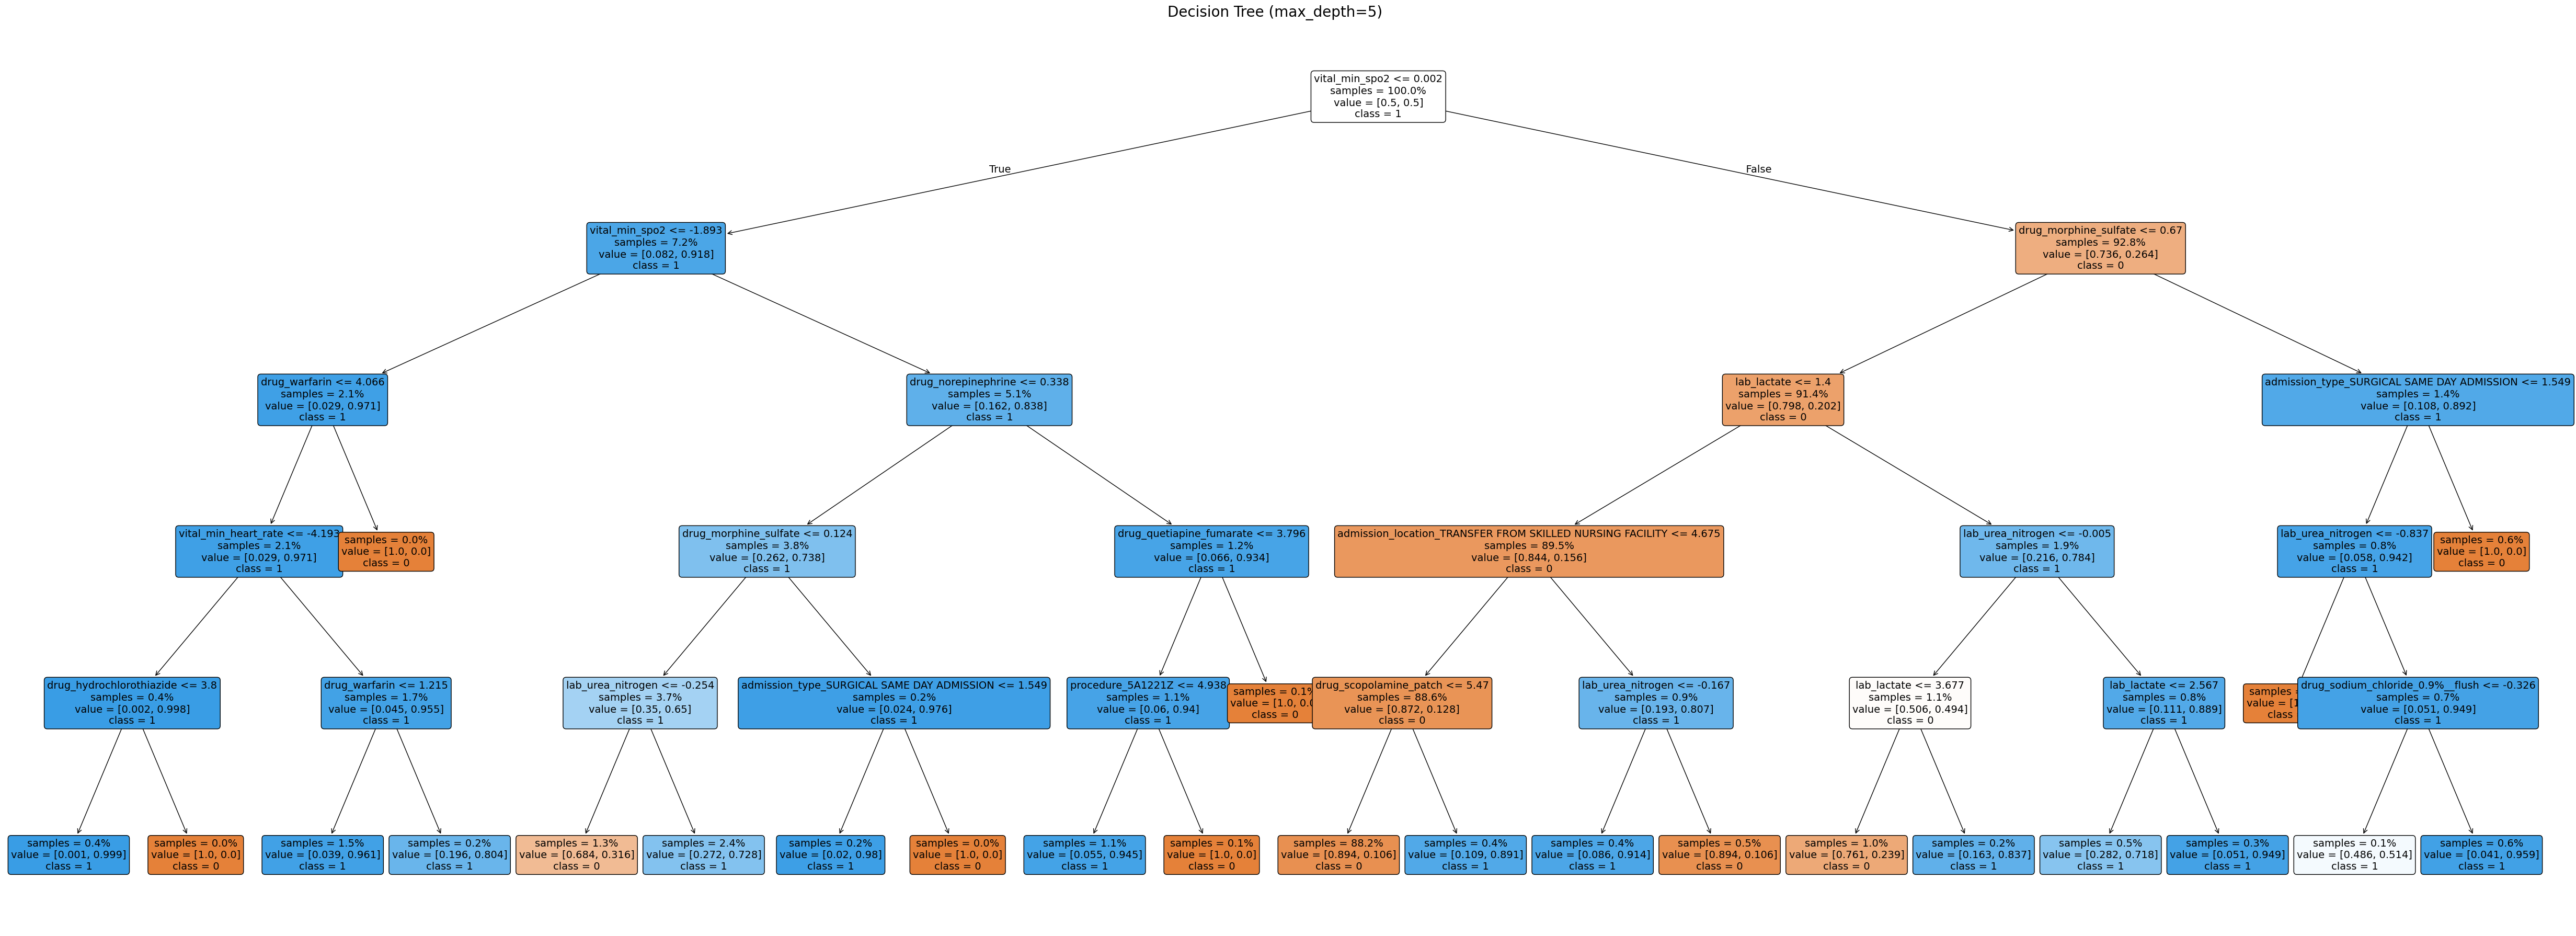

In [37]:
from sklearn import tree
import matplotlib.pyplot as plt

feature_names = list(X_train.columns)  # same order used to fit
class_names = [str(c) for c in decision_tree_model.classes_]

plt.figure(figsize=(50,18))                    # bigger canvas
ax = plt.gca()
tree.plot_tree(decision_tree_model,
               feature_names=feature_names,
               class_names=class_names,
               filled=True,
               rounded=True,
               proportion=True,
               impurity=False,
               max_depth=5,
               fontsize=14,                       # node text size
               ax=ax,
               node_ids=False)                    # optional

# increase tick label sizes (if any) and title
ax.tick_params(axis='both', which='major', labelsize=16)
plt.title("Decision Tree (max_depth=5)", fontsize=20)
plt.tight_layout()
plt.show()



Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18330     1263   (specificity 0.936)
  Actual 1          61      346   (sensitivity 0.850)

TPR (sensitivity):  0.850
FPR (fall-out):     0.064
Precision:          0.215
ROC-AUC:            0.907

              precision    recall  f1-score   support

    Survived       1.00      0.94      0.97     19593
        Died       0.22      0.85      0.34       407

    accuracy                           0.93     20000
   macro avg       0.61      0.89      0.65     20000
weighted avg       0.98      0.93      0.95     20000



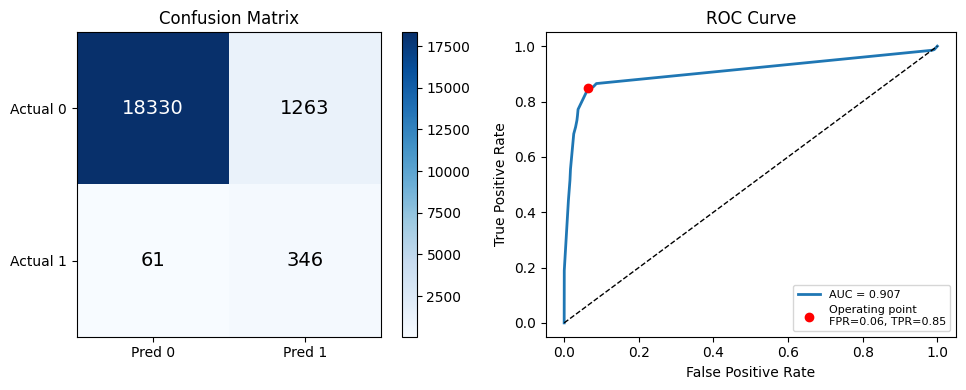

In [20]:
y_pred  = decision_tree_model.predict(X_test_scaled)
y_proba = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
decision_tree_max_depth = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_scaled, y_train)

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19422      171   (specificity 0.991)
  Actual 1         156      251   (sensitivity 0.617)

TPR (sensitivity):  0.617
FPR (fall-out):     0.009
Precision:          0.595
ROC-AUC:            0.804

              precision    recall  f1-score   support

    Survived       0.99      0.99      0.99     19593
        Died       0.59      0.62      0.61       407

    accuracy                           0.98     20000
   macro avg       0.79      0.80      0.80     20000
weighted avg       0.98      0.98      0.98     20000



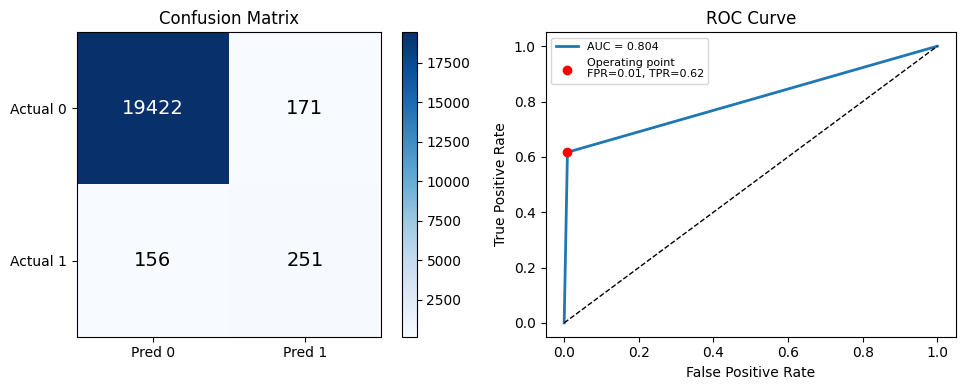

In [22]:
y_pred  = decision_tree_max_depth.predict(X_test_scaled)
y_proba = decision_tree_max_depth.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [25]:
# random_forest = RandomForestClassifier(
#     n_estimators=100, 
#     max_depth=10,
#     max_features="sqrt",
#     min_samples_leaf=5,
#     class_weight="balanced",
#     random_state=42,
#     verbose=2,
#     n_jobs=-1).fit(X_train_scaled, y_train)
random_forest = RandomForestClassifier(
    n_estimators=50, 
    max_depth=None,
    max_features="sqrt",
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    verbose=2,
    n_jobs=-1).fit(X_train_scaled, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    0.8s


building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50
building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    1.5s finished


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.0s finished


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19396      197   (specificity 0.990)
  Actual 1          94      313   (sensitivity 0.769)

TPR (sensitivity):  0.769
FPR (fall-out):     0.010
Precision:          0.614
ROC-AUC:            0.987

              precision    recall  f1-score   support

    Survived       1.00      0.99      0.99     19593
        Died       0.61      0.77      0.68       407

    accuracy                           0.99     20000
   macro avg       0.80      0.88      0.84     20000
weighted avg       0.99      0.99      0.99     20000



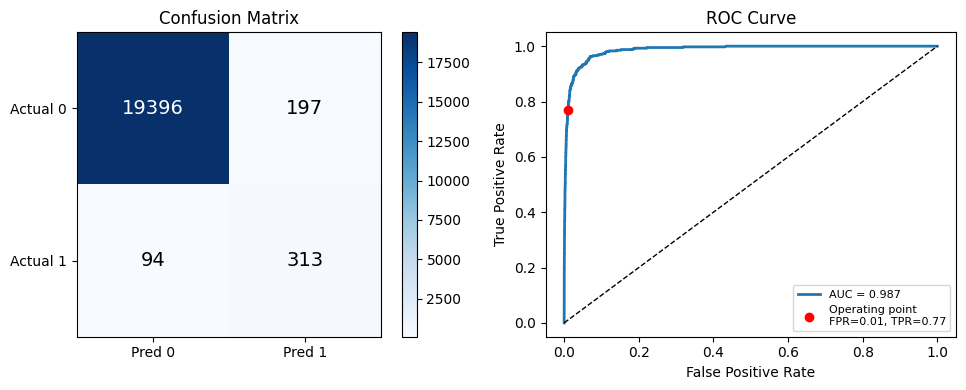

In [26]:
y_pred  = random_forest.predict(X_test_scaled)
y_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
param_dist = {
    "n_estimators": [50, 100, 200, 500, 1000],
    "max_depth": [3, 5, 20, 30, None],
    "max_features": ["sqrt", 0.2, 0.5],
    "min_samples_leaf": [1, 5, 10, 20],
    "min_samples_split": [2, 10, 20, 50],
}

clf = RandomForestClassifier(n_jobs=-1, oob_score=True, random_state=42)

rs = RandomizedSearchCV(
    clf, 
    param_dist, 
    n_iter=100, 
    cv=5, 
    scoring="roc_auc",
    n_jobs=-1, 
    random_state=42)
rs.fit(X_train, y_train)

print(rs.best_params_)

c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
105 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
105 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\redja\App

{'n_estimators': 50, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [27]:
base_estimator = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42)
adboost_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,        # reasonable starting budget for 100k samples
    learning_rate=0.5,       # reduce contribution per estimator for stability
    random_state=42
)
adboost_model.fit(X_train_scaled, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19533       60   (specificity 0.997)
  Actual 1         141      266   (sensitivity 0.654)

TPR (sensitivity):  0.654
FPR (fall-out):     0.003
Precision:          0.816
ROC-AUC:            0.986

              precision    recall  f1-score   support

    Survived       0.99      1.00      0.99     19593
        Died       0.82      0.65      0.73       407

    accuracy                           0.99     20000
   macro avg       0.90      0.83      0.86     20000
weighted avg       0.99      0.99      0.99     20000



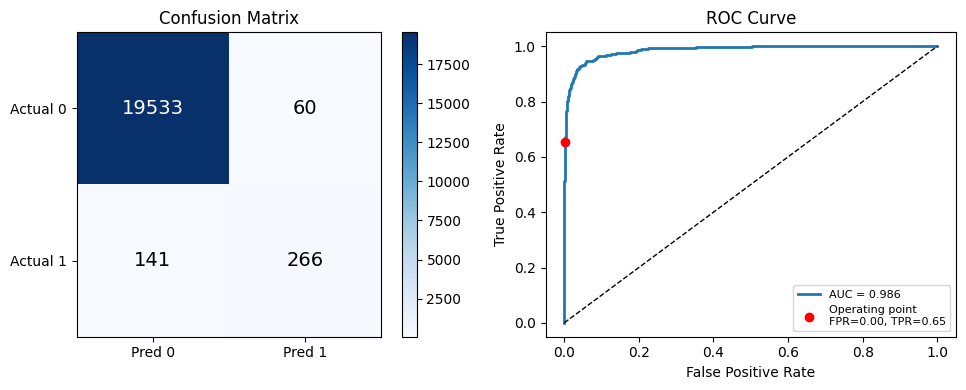

In [40]:
y_pred  = adboost_model.predict(X_test_scaled)
y_proba = adboost_model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [41]:
base_estimator = DecisionTreeClassifier(max_depth=1, min_samples_leaf=20, random_state=42)
adboost_stump_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=200,        # reasonable starting budget for 100k samples
    learning_rate=0.5,       # reduce contribution per estimator for stability
    random_state=42
)
adboost_stump_model.fit(X_train_scaled, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19543       50   (specificity 0.997)
  Actual 1         196      211   (sensitivity 0.518)

TPR (sensitivity):  0.518
FPR (fall-out):     0.003
Precision:          0.808
ROC-AUC:            0.983

              precision    recall  f1-score   support

    Survived       0.99      1.00      0.99     19593
        Died       0.81      0.52      0.63       407

    accuracy                           0.99     20000
   macro avg       0.90      0.76      0.81     20000
weighted avg       0.99      0.99      0.99     20000



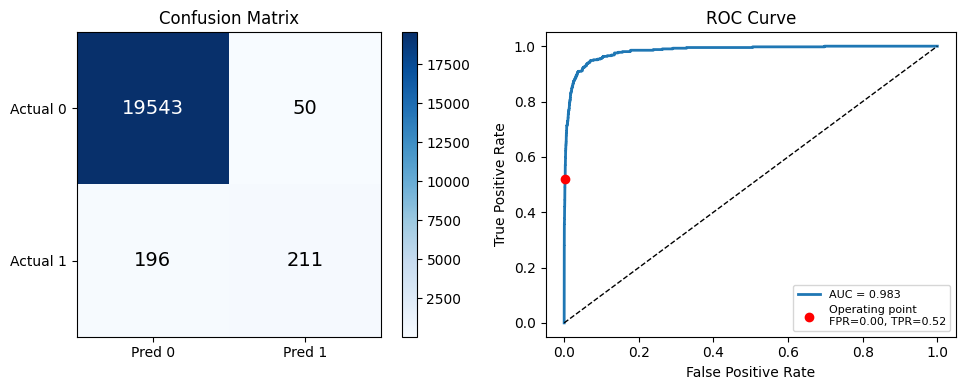

In [42]:
y_pred  = adboost_stump_model.predict(X_test_scaled)
y_proba = adboost_stump_model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()